# invoptlab quick start: clean 2D inverse optimization
This notebook generates a clean finite-choice dataset, estimates the unknown parameter with the sequential incenter, and visualizes how the normalized consistency cone changes.

If the package is not installed, run `python -m pip install -e ".[all]"` from the repository root.

In [1]:
%matplotlib inline
import numpy as np
import invoptlab as io


## 1. Create a problem and dataset
Replace this generator later with your own `ForwardProblem` and `InverseDataset`.

In [2]:
problem, dataset, theta_true = io.random_choice_experiment(
    parameter_dimension=2, observations=16, alternatives=5, seed=7
)
print('observations:', len(dataset))
print('true theta:', theta_true)


observations: 16
true theta: [-0.95241987  0.3047891 ]


## 2. Run sequential incenter estimation

In [3]:
estimator = io.IncenterEstimator(sequential_history=True)
runner = io.ExperimentRunner(io.ExperimentConfig(name='quickstart-2d', seed=7, geometry_samples=800))
result = runner.run(problem, dataset, estimator)
print('estimated theta:', result.theta)
result.metrics


estimated theta: [-0.9539023   0.30011732]


{'observed_decision_accuracy': 1.0,
 'mean_observed_decision_distance': 0.0,
 'mean_surrogate_suboptimality': 0.0,
 'max_surrogate_suboptimality': 0.0,
 'clean_decision_accuracy': 1.0,
 'mean_clean_decision_distance': 0.0,
 'mean_true_regret': 0.0,
 'cumulative_true_regret': 0.0,
 'max_true_regret': 0.0,
 'true_regret_cvar_20': 0.0,
 'parameter_angular_error': 0.004901345295997296,
 'parameter_cosine_similarity': 0.9999879884311911,
 'parameter_l1_error_normalized': 0.006154211539081245,
 'parameter_l2_error_normalized': 0.004901340389942958,
 'parameter_linf_error_normalized': 0.004671780937749781,
 'parameter_sign_accuracy': 1.0,
 'constraint_count': 64.0,
 'constraint_violation_rate': 0.0,
 'mean_constraint_violation': 0.0,
 'max_constraint_violation': 0.0,
 'minimum_margin': 0.014626407219191256,
 'median_margin': 0.7055505896453103,
 'mean_margin': 0.6084908385578791,
 'fit_time_seconds': 0.7884181999979774}

## 3. Static final cone and parameter path

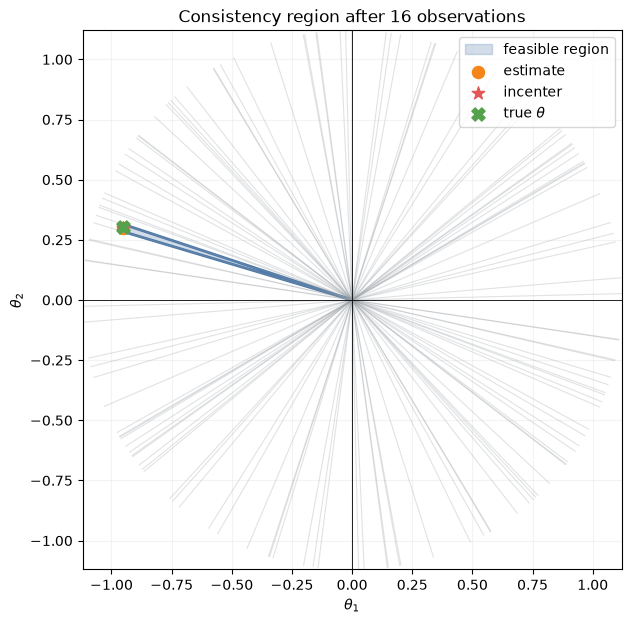

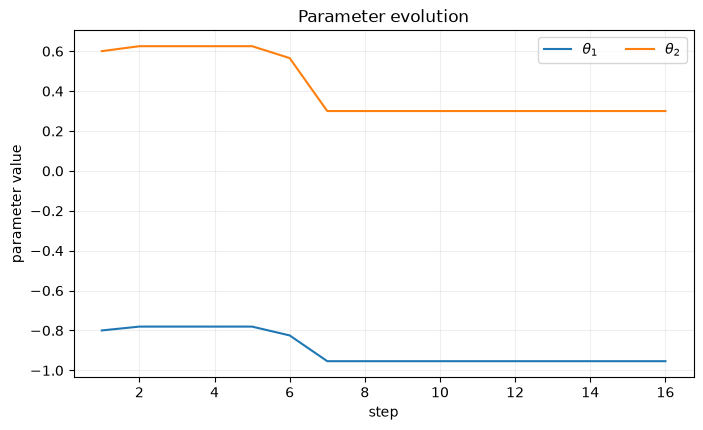

In [4]:
result.plot_cone(problem, true_theta=theta_true);
result.plot_parameters();


## 4. Interactive time animation
Use the slider or Play button to inspect every observation.

In [5]:
animation = result.animate_cone(problem, true_theta=theta_true)
animation.show()


## 5. Save all data and a standalone report

In [6]:
output = result.save('../outputs/experiments/notebook-quickstart')
report = result.generate_report(problem, dataset, output / 'report.html')
print(report)


..\outputs\experiments\notebook-quickstart\report.html
